In [1]:
######################################################
#                       _oo0oo_                      #
#                      o8888888o                     #
#                      88" . "88                     #
#                      (| -_- |)                     #
#                      0\  =  /0                     #
#                    ___/`---'\___                   #
#                  .' \\|     |// '.                 #
#                 / \\|||  :  |||// \                #
#                / _||||| -:- |||||- \               #
#               |   | \\\  -  /// |   |              #
#               | \_|  ''\---/''  |_/ |              #
#               \  .-\__  '-'  ___/-. /              #
#             ___'. .'  /--.--\  `. .'___            #
#          ."" '<  `.___\_<|>_/___.' >' "".          #
#         | | :  `- \`.;`\ _ /`;.`/ - ` : | |        #
#         \  \ `_.   \_ __\ /__ _/   .-` /  /        #
#     =====`-.____`.___ \_____/___.-`___.-'=====     #
#                       `=---='                      #
#                                                    #
#                                                    #
#     ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    #
#                                                    #
#        Buddha Bless:   "No Bugs in my code"        #
#                                                    #
######################################################

import argparse
import time
import warnings
import numpy as np
import torch

import utils
from data.preprocessing import toDataloader

warnings.filterwarnings("ignore")

#对应copy3超参数


parser = argparse.ArgumentParser()





parser = argparse.ArgumentParser()
parser.add_argument('--dataset', type=str, default='Training_Set_7P_PCA_SNmod_mock_train')
parser.add_argument('--multi_group', type=list, default=[1,2],
                    help='Input list')  # group<=math.ceil(sqrt(seq_len))
parser.add_argument('--batch', type=int, default=8, help='Dataset batch')
parser.add_argument('--lr', type=float, default=0.0001)
parser.add_argument('--nlayers', type=int, default=2)
parser.add_argument('--emb_size', type=int, default=128)
parser.add_argument('--nhead', type=int, default=8)
parser.add_argument('--emb_size_c', type=int, default=128)
parser.add_argument('--masking_ratio', type=float, default=0.01)
parser.add_argument('--epochs', type=int, default=30)
parser.add_argument('--ratio_highest_attention', type=float, default=0.35)
#parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--dropout', type=float, default=0.01)
parser.add_argument('--nhid', type=int, default=128)
parser.add_argument('--nhid_c', type=int, default=128)





args = parser.parse_args(args=[])
print(args)


def main():
    prop = utils.get_prop(args)
    prop['multi_group'] = [int(patch_index) for patch_index in prop['multi_group']]
    print('Data loading start...')
    X_train, y_train, X_test, y_test = utils.data_loader(args.dataset)
    

    prop['batch_true'] = X_train.shape[0]
    print('Data loading complete...')

    print('Data preprocessing start...')
    
    X_train_task, y_train_task, X_test, y_test,[mean_1,std_1] = utils.preprocess(X_train, y_train, X_test, y_test, prop)
    
   
    print('Norm :',[mean_1,std_1])

    
    
    
    print('After standered:', X_train_task.shape, y_train_task.shape, X_test.shape, y_test.shape)
    print(X_train_task[0].shape)

    
    
    print('Data preprocessing complete...')

    
    prop['nclasses'] = torch.max(y_train_task).item() + 1
    prop['dataset'], prop['seq_len'], prop['input_size'] = prop['dataset'], X_train_task.shape[1], X_train_task.shape[2]
    prop['device'] = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")

    # gain dataloader
    dataloader_train, dataloader_test = toDataloader(prop, X_train_task, y_train_task, X_test, y_test)

   
    print('Initializing model...')
    t = time.time()
    
    model, criterion, optimizer = utils.initialize_training(prop)
    
   
    
    #model.train()
    #=============
    print('Model intialized...')

    print('Training start...')
   
    t = time.time() - t
    print(f"\nTraining time: {t / prop['epochs']}\n")

    print('Training complete...')


if __name__ == "__main__":
    main()


Namespace(dataset='Training_Set_7P_PCA_SNmod_mock_train', multi_group=[1, 2], batch=8, lr=0.0001, nlayers=2, emb_size=128, nhead=8, emb_size_c=128, masking_ratio=0.01, epochs=30, ratio_highest_attention=0.35, dropout=0.01, nhid=128, nhid_c=128)
Data loading start...
Data loading complete...
Data preprocessing start...
原先的归一化常数 : [array([ 9.34737742e+00, -7.61012660e-01,  6.99171996e-01, -3.94168490e-01,
        1.81917543e-01,  7.59401742e-01,  9.13807511e-02, -3.73390167e-03,
       -3.53563018e-02,  3.69508791e-02,  1.01369689e-01,  3.95440374e-02,
        3.06747715e-02, -6.62989895e-02,  3.22370240e-02,  2.94120732e-02,
        1.94037771e-02, -2.64383195e-02,  7.63557682e-03,  1.75540942e-02,
       -3.31540841e-02,  2.56360634e-02, -5.87293409e-03,  9.03892601e-06,
       -2.10351605e-02, -1.21093599e-03, -7.97812556e-03, -3.68972441e-03,
       -2.13024607e-02, -3.10356758e-03,  2.82194713e-02, -8.25945978e-03,
        5.49007297e-03, -1.56512574e-04, -1.46275524e-02, -2.4835398

# 

zsh:1: command not found: nvidia-smi


Accuracy: 0.8143
F1 Score: 0.7985
Recall: 0.8143
Per-class metrics:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1356
           1       0.81      0.80      0.81      1974
           2       0.55      0.30      0.39      1316
           3       0.60      0.51      0.55       611
           4       0.81      0.65      0.72      2487
           5       0.81      1.00      0.90      4631
           6       1.00      1.00      1.00      1187

    accuracy                           0.81     13562
   macro avg       0.78      0.75      0.76     13562
weighted avg       0.80      0.81      0.80     13562



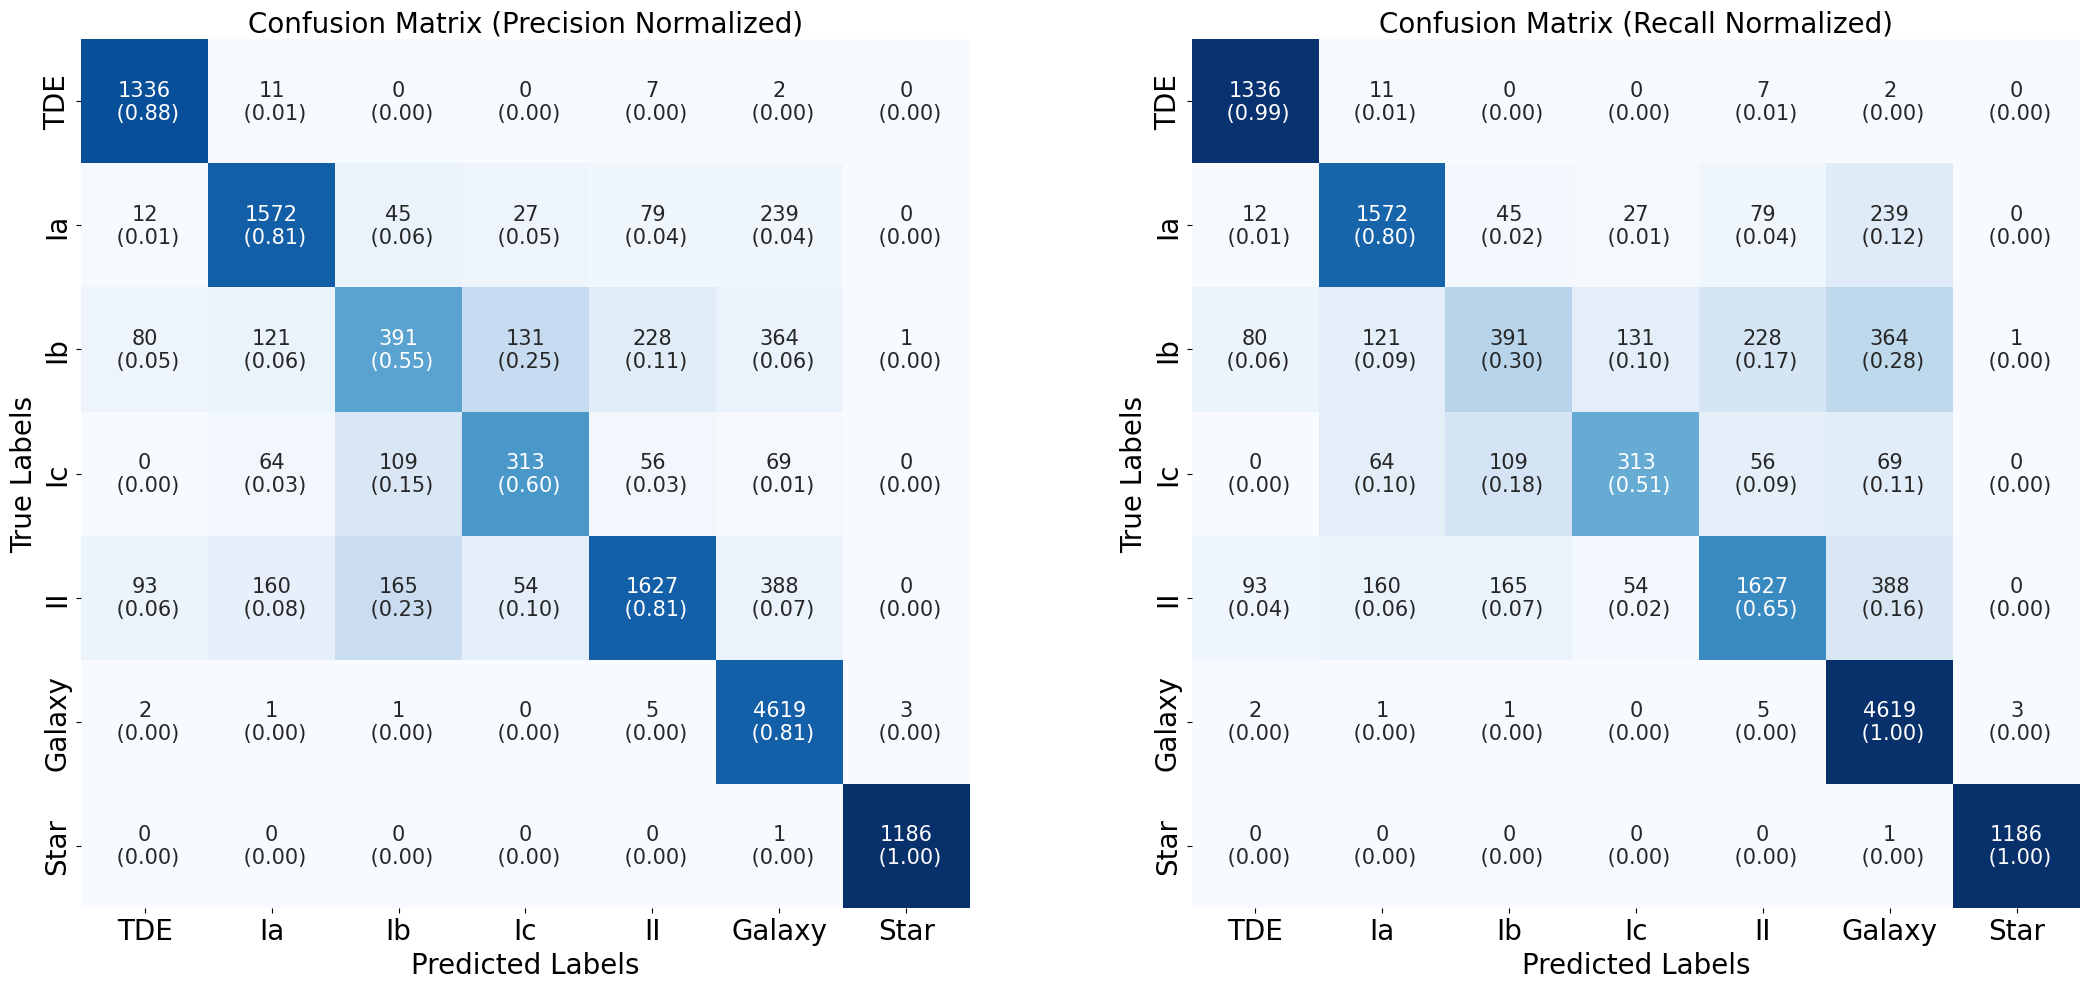

In [15]:
import math
import numpy as np
import random
import torch
import warnings
import utils

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

from moudel.mgmcformer import MgMcFORMER

from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



prop = utils.get_prop(args)

prop['multi_group'] = [int(patch_index) for patch_index in prop['multi_group']]
X_train, y_train, X_test, y_test = utils.data_loader(args.dataset)

#print(X_test)

prop['batch_true'] = X_train.shape[0]
X_train_task, y_train_task, X_test, y_test,[mean_1,std_1] = utils.preprocess(X_train, y_train, X_test, y_test, prop)
#mean_1 = [0.13601577, 0.17464775, 0.19146808]
#std_1 = [0.16609745, 0.20021448, 0.19290851]

#X_train_task, y_train_task, X_test, y_test = utils.preprocess_1(X_train, y_train, X_test, y_test, prop,[mean_1,std_1])

#print(X_test[0])

prop['nclasses'] = torch.max(y_train_task).item() + 1
prop['dataset'], prop['seq_len'], prop['input_size'] = prop['dataset'], X_train_task.shape[1], X_train_task.shape[2]
prop['device'] = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")


model = MgMcFORMER(prop['multi_group'], prop['nclasses'], prop['seq_len'], prop['input_size'], prop['emb_size'], \
                       prop['nhid'], prop['emb_size_c'], prop['nhid_c'], prop['nhead'], prop['nlayers'], prop['device'],
                       prop['dropout']).to(prop['device'])

#print(X_test)



#checkpoint = torch.load("data/ZTF_target(纯粹原始数据)-Copy1/test_model_ZTF.pth")
#print(checkpoint.keys)

dataloader_train, dataloader_test = toDataloader(prop, X_train_task, y_train_task, X_test, y_test)

#model.load_state_dict(torch.load("test_model_ZTF.pth"))
model.load_state_dict(torch.load("test_model_SP106-use5.pth"))





def test_model(model, dataloader_test, nclasses, device):
    model.eval()  # Turn on the evaluation mode

    output_arr = []
    label_arr = []
    with torch.no_grad():
        for data, label in dataloader_test:
            data = data.to(device)
            
            label = label.to(device)
            #print(data.shape)
            #print(model(data)[0].shape)
            pred = model(data)[0]
            
            output_arr.append(pred)
            label_arr.append(label)
            

    return label_arr,output_arr

nclasses=prop['nclasses']
label,output = test_model(model, dataloader_test, nclasses, device="cuda:0" )

#print(label)
#print(output)

# 将 labels 和 outputs 转换为 NumPy 数组
labels_np = torch.cat(label).cpu().numpy()
outputs_np = torch.argmax(torch.cat(output), dim=-1).cpu().numpy() 
logits = torch.cat(output)
probabilities = torch.softmax(logits, dim=-1)  # 转换为概率
#print(output)

#mask-filter
max_probs, predicted_classes = probabilities.max(dim=-1)
mask = max_probs > 0.01
#labels_np = labels_np[mask.cpu().numpy()]  # 只保留对应元素
#outputs_np = outputs_np[mask.cpu().numpy()]  # 同样筛选对应的预测


def prob_label_remix(probs,labels):
    for i in range(len(labels)):
        '''
        if probs[i][0] < 0.7 and probs[i][0] == np.max(np.array(probs[i].cpu())):
            # 获取两个最大值的下标
            top2_indices = probs[i].argsort()[-2:]
            # 最大的那个是最后一个，次大的那个是前一个
            second_max_index = top2_indices[0] if top2_indices[1] == 1 else top2_indices[1]
            labels[i] = second_max_index
        
        if probs[i][4]>=0.1:
            labels[i]=4
        '''
        if probs[i][0]>=0.05:
            labels[i]=0
        

        
        
        
        
       
       

    return labels
    pass


def wash_labels(labels,preds,probs):
    new_labels = [];new_preds = []
    for i in range(len(labels)):
        pro1 = np.array(probs[i].cpu())
        
        if np.max(np.array(probs[i].cpu()))>0.7:
            new_labels.append(labels[i])
            new_preds.append(preds[i])

    return new_labels,new_preds

labels_np = labels_np



directories = ['TDE',  'Ia','Ib','Ic','II','Galaxy','Star']

labels = np.arange(0,7,1 )
label_map = {labels[i]: directories[i] for i in range(len(labels))}

accuracy = accuracy_score(labels_np, outputs_np)
f1 = f1_score(labels_np, outputs_np, average='weighted')
recall = recall_score(labels_np, outputs_np, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")

print("Per-class metrics:")
print(classification_report(labels_np, outputs_np))


# 计算混淆矩阵
cm = confusion_matrix(labels_np, outputs_np)

# 归一化处理
cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)
cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 绘制热图
plt.figure(figsize=(21, 10))

# 精确度归一化
plt.subplot(1, 2, 1)
annot_text = [[f"{cm[i, j]}\n ({cm_precision[i, j]:.2f})" if cm[j, :].sum() != 0 else f"{cm[i, j]}\n (N/A)" 
               for j in range(cm.shape[1])] for i in range(cm.shape[0])]
ax = sns.heatmap(cm_precision, annot=annot_text, fmt="", cmap="Blues", cbar=False,
            xticklabels=[label_map.get(i, i) for i in np.unique(labels_np)], 
            yticklabels=[label_map.get(i, i) for i in np.unique(labels_np)],
            annot_kws={"size": 15})
ax.tick_params(axis='x', labelsize=20)  # x轴标签字体大小
ax.tick_params(axis='y', labelsize=20)  # y轴标签字体大小
plt.xlabel('Predicted Labels',fontsize=20)
plt.ylabel('True Labels',fontsize=20)
plt.title('Confusion Matrix (Precision Normalized)',fontsize=20)

# 召回率归一化
plt.subplot(1, 2, 2)
annot_text = [[f"{cm[i, j]}\n ({cm_recall[i, j]:.2f})" if cm[i, :].sum() != 0 else f"{cm[i, j]}\n (N/A)" 
               for j in range(cm.shape[1])] for i in range(cm.shape[0])]
ax = sns.heatmap(cm_recall, annot=annot_text, fmt="", cmap="Blues", cbar=False,
            xticklabels=[label_map.get(i, i) for i in np.unique(labels_np)], 
            yticklabels=[label_map.get(i, i) for i in np.unique(labels_np)],
           annot_kws={"size": 15})
ax.tick_params(axis='x', labelsize=20)  # x轴标签字体大小
ax.tick_params(axis='y', labelsize=20)  # y轴标签字体大小

plt.xlabel('Predicted Labels',fontsize=20)
plt.ylabel('True Labels',fontsize=20)
#plt.title('Confusion Matrix (Recall Normalized) - score>0.05',fontsize=20)
plt.title('Confusion Matrix (Recall Normalized)',fontsize=20)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig('model_another_s10.png')
plt.show()

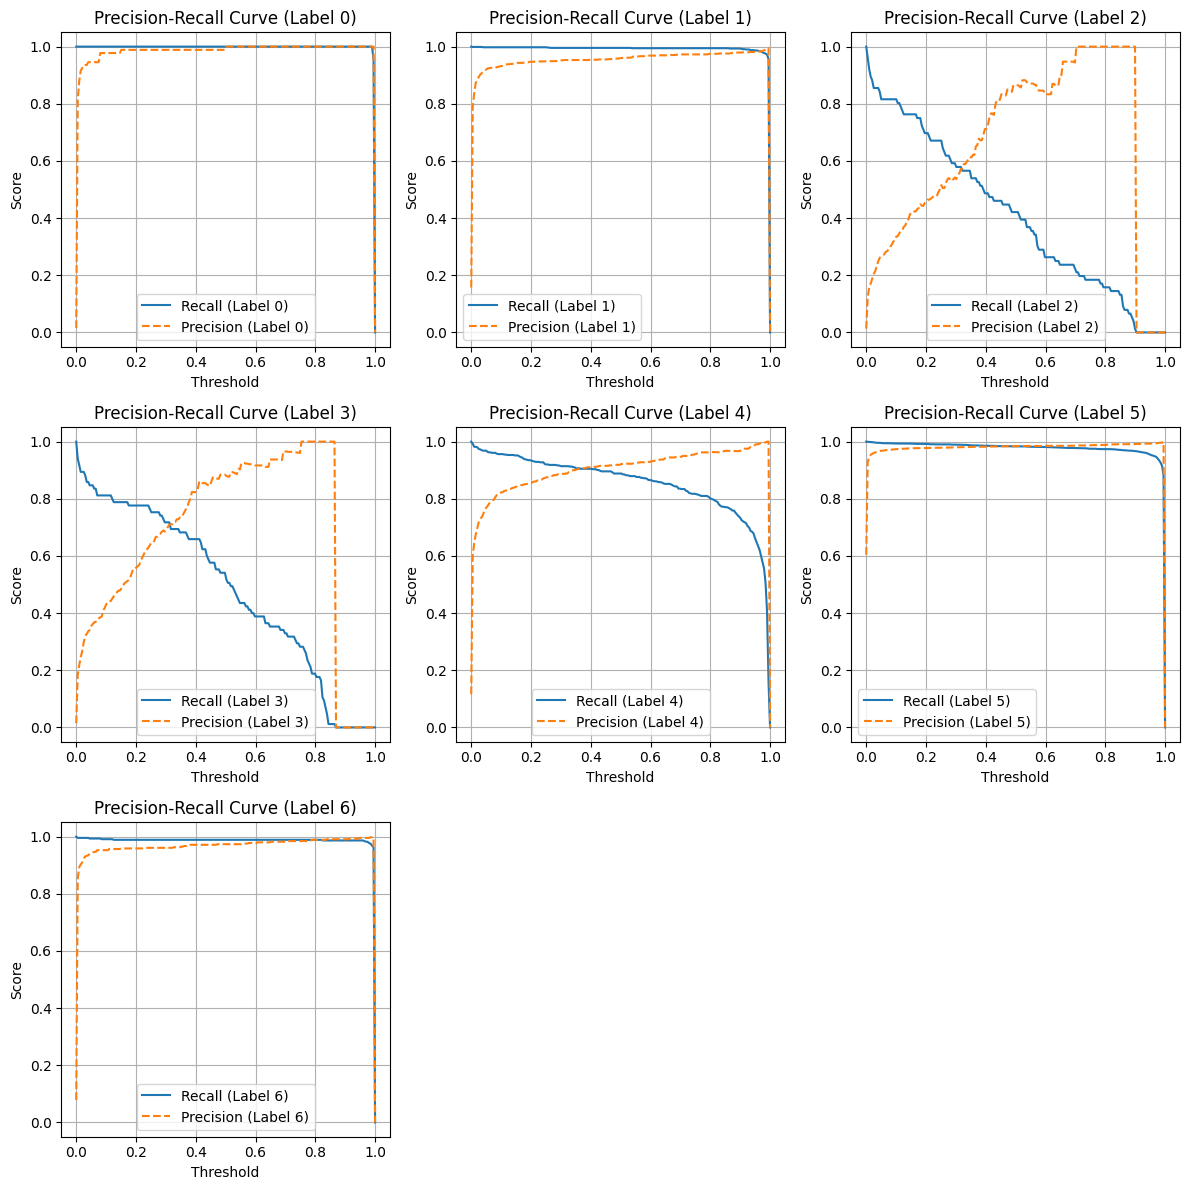

In [17]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_multi_label_precision_recall_curve(
    label_list,
    output_list,
    target_labels,
    num_thresholds=200,
    plot=True,
    separate_plots=False
):
    """
    计算并绘制多个 target_label 的 Precision 和 Recall 随概率阈值变化的曲线。

    参数:
    - label_list: list of torch.Tensor，真实标签
    - output_list: list of torch.Tensor，模型输出（logits）
    - target_labels: list of int，待分析的类别
    - num_thresholds: int，阈值数量（精度）
    - plot: bool，是否画图
    - separate_plots: bool，是否每个类别单独画图

    返回:
    - results: dict，每个 label 下对应的 (thresholds, precisions, recalls)
    """
    
    labels_np = torch.cat(label_list).cpu().numpy()
    logits = torch.cat(output_list)
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()
    outputs_np = np.argmax(probabilities, axis=-1)

    thresholds = np.linspace(0.0, 1.0, num_thresholds)
    results = {}

    for target_label in target_labels:
        recalls = []
        precisions = []

        for threshold in thresholds:
            adjusted_labels = outputs_np.copy()
            for i in range(len(adjusted_labels)):
                if probabilities[i][target_label] >= threshold:
                    adjusted_labels[i] = target_label
                else:
                    adjusted_labels[i] = -1  # 非目标类

            binary_true = (labels_np == target_label).astype(int)
            binary_pred = (adjusted_labels == target_label).astype(int)

            cm = confusion_matrix(binary_true, binary_pred, labels=[0, 1])
            cm_precision = cm.astype('float') / cm.sum(axis=0, keepdims=True)
            cm_recall = cm.astype('float') / cm.sum(axis=1, keepdims=True)

            precision = cm_precision[1, 1] if not np.isnan(cm_precision[1, 1]) else 0.0
            recall = cm_recall[1, 1] if not np.isnan(cm_recall[1, 1]) else 0.0

            precisions.append(precision)
            recalls.append(recall)

        results[target_label] = (thresholds, np.array(precisions), np.array(recalls))

    # 可视化
    if plot:
        if separate_plots:
            num_labels = len(target_labels)
            ncols = 3
            nrows = int(np.ceil(num_labels / ncols))
            fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))

            axs = axs.flatten() if num_labels > 1 else [axs]

            for idx, target_label in enumerate(target_labels):
                t, p, r = results[target_label]
                ax = axs[idx]
                ax.plot(t, r, label=f'Recall (Label {target_label})')
                ax.plot(t, p, '--', label=f'Precision (Label {target_label})')
                ax.set_title(f"Precision-Recall Curve (Label {target_label})")
                ax.set_xlabel("Threshold")
                ax.set_ylabel("Score")
                ax.legend()
                ax.grid(True)

            # 清理多余的子图
            for i in range(len(target_labels), len(axs)):
                fig.delaxes(axs[i])

            plt.tight_layout()
            plt.show()

        else:
            plt.figure(figsize=(10, 6))
            for target_label in target_labels:
                t, p, r = results[target_label]
                plt.plot(t, r, label=f'Recall (Label {target_label})')
                plt.plot(t, p, '--', label=f'Precision (Label {target_label})')
            plt.title("Precision-Recall Curves")
            plt.xlabel("Threshold")
            plt.ylabel("Score")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    return results


res = plot_multi_label_precision_recall_curve(label, output, target_labels=[0,1,2,3,4,5,6], separate_plots=True)